In [1]:
import os
from pprint import pprint
import pickle as pkl
import glob
import shutil
import copy
import json

import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as scipy_R
from tqdm.auto import tqdm
from ultralytics import RTDETR
import networkx as nx

import cv2
import open3d as o3d
import matplotlib.pyplot as plt
import matplotlib.patches as patches
np.set_printoptions(suppress=True)

from preprocess import MapGraph, QueryGraph
from preprocess.scannet_utils import ScanNetLoader, get_fov, create_color_map, create_camera_frame, create_cuboid

from utils import (
    comp_graph_overlap,
    transform_bbox3d,
    invert_Rt,
    compute_IoU_x0y0wh,
    compute_IoU_xyxy
)

from eva import (
    compute_pose_error,
)

from viz_utils import (
    viz_bbox3d_with_plotly,
)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
SCANNET_PATH = 'data/ScanNet/scannet_by_tr3d_with_DepthImage'
scannet_loader = ScanNetLoader(SCANNET_PATH)

In [3]:
SCENE_ID = 'scene0000_00'
FRAME_ID = '00100'

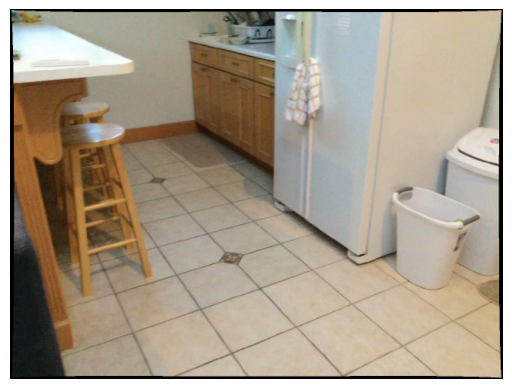

In [4]:
rgb_img = scannet_loader.get_rgb_img(SCENE_ID, FRAME_ID)
bbox2d_df = scannet_loader.get_bbox2d(SCENE_ID, FRAME_ID)
fig, ax = plt.subplots()
ax.imshow(rgb_img)
# for i, bbox2d in bbox2d_df.iterrows():
#     label_id = bbox2d['c']
#     label_name = scannet_loader.get_label_names([label_id], 'nyu40class')[0]
#     text = f'{label_id}: {label_name}'
#     rect = patches.Rectangle((bbox2d['x0'], bbox2d['y0']), bbox2d['w'], bbox2d['h'],
#                                 linewidth=1, edgecolor='r', facecolor='none')
#     ax.text(bbox2d['x0'], bbox2d['y0'] + bbox2d['h'], text, color='r')
#     ax.add_patch(rect)
ax.axis('off')
plt.show()

In [5]:
def get_frame_ids(scene_id: str):
    frame_paths = glob.glob(os.path.join(SCANNET_PATH, 'posed_images', scene_id, '*.jpg'))
    frame_ids = list(set([int(os.path.basename(frame_path).split('.')[0]) for frame_path in frame_paths]))
    return frame_ids

In [7]:
df, _ = scannet_loader.get_bbox3d_and_align_matrix(SCENE_ID)
labels = df['c'].astype(int).astype(str).values
bbox3d = df[['x', 'y', 'z']].copy().rename(columns={'x': 'tx', 'y': 'ty', 'z': 'tz'})
bbox3d['qx'] = 0
bbox3d['qy'] = 0
bbox3d['qz'] = 0
bbox3d['qw'] = 1
bbox3d[['sx', 'sy', 'sz']] = df[['dx', 'dy', 'dz']] / 2

viz_bbox3d_with_plotly(bbox3d.values, labels, fig_size=(1200, 1200))

In [105]:
aligned_bbox3d_df, align_matrix = scannet_loader.get_bbox3d_and_align_matrix(SCENE_ID)
cam_t, cam_R = scannet_loader.get_cam_pose(SCENE_ID, FRAME_ID, align_matrix)
# Convert quaternion to rotation matrix
rot_matrix = cam_R.as_matrix()
# Define a color map for categories
num_categories = int(np.max(aligned_bbox3d_df.values[:, -1])) + 1
color_map = create_color_map(num_categories)
# Create an Open3D visualization window
vis = o3d.visualization.Visualizer()
vis.create_window()
# Add camera frame to the visualization
camera_frame = create_camera_frame(cam_t, rot_matrix)
vis.add_geometry(camera_frame)
# Add objects as cuboids
for obj in aligned_bbox3d_df.values:
    position = obj[:3]
    size = obj[3:6]
    category = int(obj[6])
    color = color_map[category]
    cuboid, cuboid_frame = create_cuboid(position, size, color=color)
    vis.add_geometry(cuboid)
    # vis.add_geometry(cuboid_frame)
# Run the visualizer
vis.run()
vis.destroy_window()

In [104]:
K = scannet_loader.get_intrinsics(SCENE_ID)
img_size = scannet_loader.img_size
frame_ids = get_frame_ids(SCENE_ID)
pcd = o3d.geometry.PointCloud()
for frame_id in tqdm(frame_ids):
    _, align_matrix = scannet_loader.get_bbox3d_and_align_matrix(SCENE_ID)
    cam_pose = scannet_loader.get_cam_pose(SCENE_ID, frame_id, align_matrix)
    cam_T = np.eye(4)
    cam_T[:3, :3] = cam_pose[1].as_matrix()
    cam_T[:3, 3] = cam_pose[0]
    rgb = scannet_loader.get_rgb_img(SCENE_ID, frame_id)
    depth = scannet_loader.get_depth_img_in_m(SCENE_ID, frame_id) * 1000
    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        o3d.geometry.Image(rgb), o3d.geometry.Image(depth), convert_rgb_to_intensity=False)
    pcd_local = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, o3d.camera.PinholeCameraIntrinsic(
        width=img_size[1], height=img_size[0], fx=K[0, 0], fy=K[1, 1], cx=K[0, 2], cy=K[1, 2]))
    pcd_local.transform(cam_T)
    pcd += pcd_local
pcd = pcd.voxel_down_sample(voxel_size=0.02)
o3d.visualization.draw_geometries([pcd]) 

  0%|          | 0/300 [00:00<?, ?it/s]